# PyTorch digit classification with Optuna — GPU

This notebook extends the GPU PyTorch example by adding Optuna hyperparameter tuning.

Optuna chooses hyperparameters, while each PyTorch trial is trained and validated on the GPU.

The test set remains untouched until the best hyperparameters have been selected.


In [1]:
# Run once if Optuna is not installed in the current environment:
# %pip install optuna


In [2]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour
)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)


## Check CUDA

Optuna itself manages the search on the CPU, while the PyTorch model created inside each trial is moved to the GPU.


In [3]:
print("PyTorch version:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Optuna version:", optuna.__version__)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Make sure this notebook is using the CUDA-enabled "
        "PyTorch environment."
    )

device = torch.device("cuda")

print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.14.0+cu130
CUDA build: 13.0
CUDA available: True
Optuna version: 5.0.0
Using device: cuda
GPU: NVIDIA GeForce GTX 1650


## Prepare train, validation, and test sets

The dataset is split into three parts:

- training data — used to fit each trial,
- validation data — used by Optuna to compare hyperparameters,
- test data — used only for final evaluation.


In [4]:
digits = load_digits()

X = digits.data
y = digits.target

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.2,
    random_state=42,
    stratify=y_dev
)

X_train = X_train / 16.0
X_val = X_val / 16.0
X_test = X_test / 16.0

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Training set: (1149, 64)
Validation set: (288, 64)
Test set: (360, 64)


In [5]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


## Define a configurable neural network

The hidden-layer sizes are configurable so Optuna can try different network architectures.


In [6]:
class DigitClassifier(nn.Module):
    def __init__(self, hidden1=128, hidden2=64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(64, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.network(x)


## Define the Optuna objective

Each trial chooses:

- first hidden-layer size,
- second hidden-layer size,
- learning rate,
- batch size.

A fresh model is created for every trial, trained on GPU, and scored using validation accuracy.


In [7]:
def objective(trial):

    hidden1 = trial.suggest_categorical(
        "hidden1",
        [64, 128, 256]
    )

    hidden2 = trial.suggest_categorical(
        "hidden2",
        [32, 64, 128]
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64]
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = DigitClassifier(
        hidden1=hidden1,
        hidden2=hidden2
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    epochs = 25

    for epoch in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        val_outputs = model(
            X_val_tensor.to(device)
        )

        val_predictions = torch.argmax(
            val_outputs,
            dim=1
        )

    val_accuracy = accuracy_score(
        y_val,
        val_predictions.cpu().numpy()
    )

    # Free objects from this trial before the next one.
    del model
    del optimizer
    del val_outputs
    del val_predictions

    gc.collect()
    torch.cuda.empty_cache()

    return val_accuracy


## Run the Optuna study

We use 20 trials to keep the experiment small while still exploring multiple hyperparameter combinations.


In [8]:
study = optuna.create_study(
    direction="maximize"
)

torch.cuda.synchronize()
start_time = time.perf_counter()

study.optimize(
    objective,
    n_trials=20
)

torch.cuda.synchronize()
optuna_time = time.perf_counter() - start_time

print(f"Optuna tuning time: {optuna_time:.2f} seconds")


[I 2026-09-19 23:21:42,427] A new study created in memory with name: no-name-ea8942f1-67dc-4313-97ea-b056d75fd726
[I 2026-09-19 23:21:47,801] Trial 0 finished with value: 0.9756944444444444 and parameters: {'hidden1': 128, 'hidden2': 128, 'learning_rate': 0.001092147197493769, 'batch_size': 32}. Best is trial 0 with value: 0.9756944444444444.
[I 2026-09-19 23:21:52,734] Trial 1 finished with value: 0.9652777777777778 and parameters: {'hidden1': 128, 'hidden2': 32, 'learning_rate': 0.0005391367248263882, 'batch_size': 16}. Best is trial 0 with value: 0.9756944444444444.
[I 2026-09-19 23:21:58,330] Trial 2 finished with value: 0.9618055555555556 and parameters: {'hidden1': 128, 'hidden2': 32, 'learning_rate': 0.00012968823454623138, 'batch_size': 16}. Best is trial 0 with value: 0.9756944444444444.
[I 2026-09-19 23:22:00,309] Trial 3 finished with value: 0.96875 and parameters: {'hidden1': 128, 'hidden2': 32, 'learning_rate': 0.0009351626034183859, 'batch_size': 64}. Best is trial 0 with

Optuna tuning time: 79.78 seconds


In [9]:
print("Best validation accuracy:", study.best_value)

print("\nBest hyperparameters:")

for key, value in study.best_params.items():
    print(f"{key}: {value}")


Best validation accuracy: 0.9930555555555556

Best hyperparameters:
hidden1: 256
hidden2: 32
learning_rate: 0.007041274252441032
batch_size: 16


In [10]:
# Convert Optuna trials to a DataFrame
trials_df = study.trials_dataframe()

print("Top trials:")

display(
    trials_df[
        [
            "number",
            "value",
            "params_hidden1",
            "params_hidden2",
            "params_learning_rate",
            "params_batch_size"
        ]
    ]
    .sort_values("value", ascending=False)
    .head(10)
)

# 1. Optimization history
plot_optimization_history(study).show()

# 2. Hyperparameter importance
plot_param_importances(study).show()

Top trials:


,number,value,params_hidden1,params_hidden2,params_learning_rate,params_batch_size
8,8,0.993056,256,32,0.007041,16
12,12,0.989583,256,32,0.008547,16
10,10,0.986111,64,32,0.008829,16
11,11,0.986111,64,32,0.009300,16
15,15,0.986111,256,32,0.009568,64
17,17,0.986111,256,128,0.001775,16
14,14,0.982639,256,128,0.006168,64
18,18,0.982639,256,64,0.005855,16
0,0,0.975694,128,128,0.001092,32
19,19,0.972222,256,32,0.001761,64


In [11]:
# 3. Parallel-coordinate plot
plot_parallel_coordinate(
    study,
    params=[
        "learning_rate",
        "batch_size",
        "hidden1",
        "hidden2"
    ]
).show()


# 4. 2D contour plot
plot_contour(
    study,
    params=[
        "learning_rate",
        "hidden1"
    ]
).show()

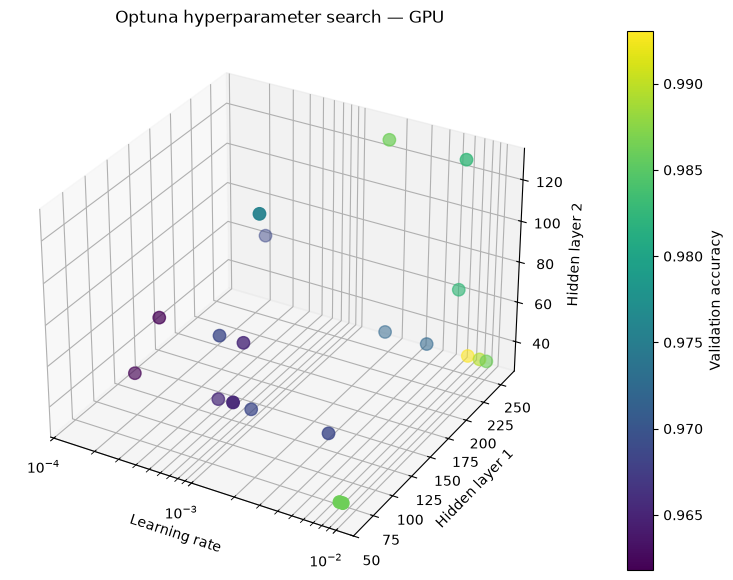

In [12]:
# ------------------------------------------------------------
# 5. 3D hyperparameter search visualization
# ------------------------------------------------------------

df = study.trials_dataframe().dropna(
    subset=[
        "value",
        "params_learning_rate",
        "params_hidden1",
        "params_hidden2"
    ]
)

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    df["params_learning_rate"],
    df["params_hidden1"],
    df["params_hidden2"],
    c=df["value"],
    s=80
)

ax.set_xlabel("Learning rate")
ax.set_ylabel("Hidden layer 1")
ax.set_zlabel("Hidden layer 2")

ax.set_title(
    "Optuna hyperparameter search — GPU"
)

ax.set_xscale("log")

colorbar = plt.colorbar(
    scatter,
    ax=ax,
    pad=0.1
)

colorbar.set_label(
    "Validation accuracy"
)

plt.show()

## Inspect Optuna trials

The following cells show the trial table and validation accuracy across the search.


In [13]:
trials_df = study.trials_dataframe()

trials_df[
    [
        "number",
        "value",
        "params_hidden1",
        "params_hidden2",
        "params_learning_rate",
        "params_batch_size"
    ]
].sort_values(
    "value",
    ascending=False
).head(10)


,number,value,params_hidden1,params_hidden2,params_learning_rate,params_batch_size
8,8,0.993056,256,32,0.007041,16
12,12,0.989583,256,32,0.008547,16
10,10,0.986111,64,32,0.008829,16
11,11,0.986111,64,32,0.009300,16
15,15,0.986111,256,32,0.009568,64
17,17,0.986111,256,128,0.001775,16
14,14,0.982639,256,128,0.006168,64
18,18,0.982639,256,64,0.005855,16
0,0,0.975694,128,128,0.001092,32
19,19,0.972222,256,32,0.001761,64


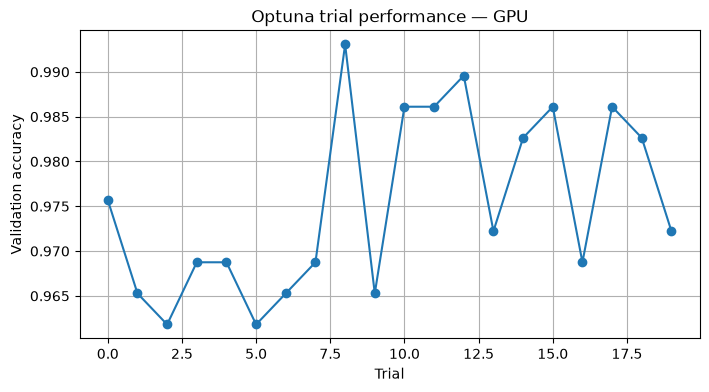

In [14]:
plt.figure(figsize=(8, 4))

plt.plot(
    trials_df["number"],
    trials_df["value"],
    marker="o"
)

plt.xlabel("Trial")
plt.ylabel("Validation accuracy")
plt.title("Optuna trial performance — GPU")
plt.grid(True)

plt.show()


## Retrain the best model

After tuning, the original training and validation data are combined. A final model is trained using the best Optuna hyperparameters before evaluating on the untouched test set.


In [15]:
best_params = study.best_params

X_final_train = np.vstack([
    X_train,
    X_val
])

y_final_train = np.concatenate([
    y_train,
    y_val
])

X_final_train_tensor = torch.tensor(
    X_final_train,
    dtype=torch.float32
)

y_final_train_tensor = torch.tensor(
    y_final_train,
    dtype=torch.long
)

final_dataset = TensorDataset(
    X_final_train_tensor,
    y_final_train_tensor
)

final_loader = DataLoader(
    final_dataset,
    batch_size=best_params["batch_size"],
    shuffle=True
)

final_model = DigitClassifier(
    hidden1=best_params["hidden1"],
    hidden2=best_params["hidden2"]
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_params["learning_rate"]
)


In [16]:
epochs = 20
loss_history = []

torch.cuda.synchronize()
start_time = time.perf_counter()

for epoch in range(epochs):
    final_model.train()
    running_loss = 0.0

    for X_batch, y_batch in final_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(final_loader)
    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

torch.cuda.synchronize()
final_training_time = time.perf_counter() - start_time

print(
    f"\nFinal GPU training time: "
    f"{final_training_time:.4f} seconds"
)


Epoch 01/20 - Loss: 0.8848
Epoch 02/20 - Loss: 0.2181
Epoch 03/20 - Loss: 0.1269
Epoch 04/20 - Loss: 0.1188
Epoch 05/20 - Loss: 0.0833
Epoch 06/20 - Loss: 0.0506
Epoch 07/20 - Loss: 0.0364
Epoch 08/20 - Loss: 0.0400
Epoch 09/20 - Loss: 0.0579
Epoch 10/20 - Loss: 0.0225
Epoch 11/20 - Loss: 0.0314
Epoch 12/20 - Loss: 0.0129
Epoch 13/20 - Loss: 0.0091
Epoch 14/20 - Loss: 0.0053
Epoch 15/20 - Loss: 0.0151
Epoch 16/20 - Loss: 0.0904
Epoch 17/20 - Loss: 0.0398
Epoch 18/20 - Loss: 0.0226
Epoch 19/20 - Loss: 0.0015
Epoch 20/20 - Loss: 0.0005

Final GPU training time: 5.6059 seconds


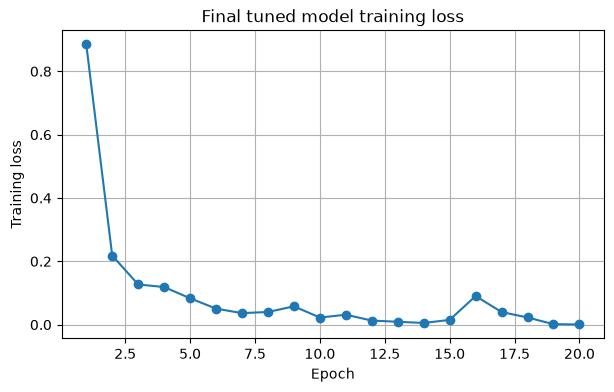

In [17]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Final tuned model training loss")
plt.grid(True)

plt.show()


## Final test evaluation

The final test set has not been used during the Optuna search, so this gives the cleanest estimate of the tuned model's performance.


In [18]:
final_model.eval()

with torch.no_grad():
    test_outputs = final_model(
        X_test_tensor.to(device)
    )

    test_predictions = torch.argmax(
        test_outputs,
        dim=1
    )

test_predictions_np = (
    test_predictions
    .cpu()
    .numpy()
)

test_accuracy = accuracy_score(
    y_test,
    test_predictions_np
)

print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"Final test accuracy: {test_accuracy * 100:.2f}%")


Final test accuracy: 0.9778
Final test accuracy: 97.78%


In [19]:
print(
    classification_report(
        y_test,
        test_predictions_np
    )
)


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.97      0.95        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      1.00      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      0.94      0.97        36
           7       1.00      0.97      0.99        36
           8       0.92      0.94      0.93        35
           9       1.00      0.97      0.99        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



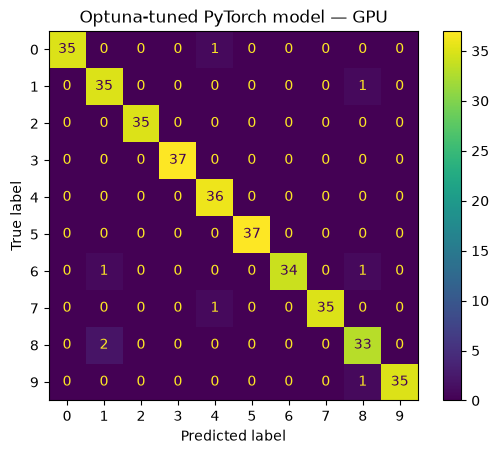

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions_np
)

plt.title("Optuna-tuned PyTorch model — GPU")
plt.show()


In [21]:
print("GPU memory allocated:",
      f"{torch.cuda.memory_allocated() / 1024**2:.2f} MB")

print("GPU memory reserved:",
      f"{torch.cuda.memory_reserved() / 1024**2:.2f} MB")


GPU memory allocated: 16.66 MB
GPU memory reserved: 22.00 MB


## Summary

This notebook combines:

`Optuna hyperparameter search → PyTorch GPU training → validation selection → final retraining → untouched test evaluation`

Optuna chooses the hyperparameters, while PyTorch performs the actual neural-network computation on the GPU.
